In [1]:
!pip install -q ultralytics opencv-python pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 6.0 MB/s eta 0:00:00


In [2]:
import os
import sys
import torch
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: 8.4.161
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


# Dataset paths

In [3]:
from pathlib import Path

DATASET_ROOT = Path(
    "/kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000"
)

print("Dataset exists:", DATASET_ROOT.exists())

for path in DATASET_ROOT.iterdir():
    print(path)

Dataset exists: True
/kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K


In [4]:
from pathlib import Path

DATASET_ROOT = Path(
    "/kaggle/input/datasets/adityaudai1305/"
    "rdd2022-datasets-10000/RDD2022_CJU_10K"
)

print("=" * 70)
print("ACTUAL DATASET")
print("=" * 70)

print("Path:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

print("\nContents:")

for item in sorted(DATASET_ROOT.iterdir()):

    if item.is_dir():
        print(f"[DIR]  {item.name}")
    else:
        print(f"[FILE] {item.name}")

ACTUAL DATASET
Path: /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K
Exists: True

Contents:
[FILE] data.yaml
[DIR]  test
[DIR]  train
[DIR]  val


In [5]:
from pathlib import Path
from collections import Counter

DATASET_ROOT = Path(
    "/kaggle/input/datasets/adityaudai1305/"
    "rdd2022-datasets-10000/RDD2022_CJU_10K"
)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

print("=" * 70)
print("RDD2022 10K DATASET VERIFICATION")
print("=" * 70)

print("Dataset:")
print(DATASET_ROOT)

# ------------------------------------------------------------
# FIND SPLIT DIRECTORIES
# ------------------------------------------------------------

split_paths = {}

for split in ["train", "val", "test"]:

    matches = [
        p for p in DATASET_ROOT.rglob(split)
        if p.is_dir()
    ]

    if matches:
        split_paths[split] = matches[0]

print("\n" + "=" * 70)
print("SPLITS FOUND")
print("=" * 70)

for split in ["train", "val", "test"]:

    if split in split_paths:
        print(
            f"✓ {split.upper():5s}: "
            f"{split_paths[split]}"
        )
    else:
        print(
            f"❌ {split.upper():5s}: NOT FOUND"
        )

# ------------------------------------------------------------
# FIND IMAGES / LABELS
# ------------------------------------------------------------

stats = {}

for split in ["train", "val", "test"]:

    if split not in split_paths:
        continue

    split_dir = split_paths[split]

    image_dirs = [
        p for p in split_dir.rglob("images")
        if p.is_dir()
    ]

    label_dirs = [
        p for p in split_dir.rglob("labels")
        if p.is_dir()
    ]

    if image_dirs:
        images_dir = image_dirs[0]
    else:
        images_dir = split_dir

    if label_dirs:
        labels_dir = label_dirs[0]
    else:
        labels_dir = None

    images = [
        p for p in images_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if labels_dir:

        labels = [
            p for p in labels_dir.rglob("*.txt")
            if p.is_file()
        ]

    else:
        labels = []

    image_stems = {
        p.stem
        for p in images
    }

    label_stems = {
        p.stem
        for p in labels
    }

    missing_labels = (
        image_stems - label_stems
    )

    orphan_labels = (
        label_stems - image_stems
    )

    stats[split] = {
        "images": images,
        "labels": labels,
        "image_stems": image_stems,
        "label_stems": label_stems,
        "missing_labels": missing_labels,
        "orphan_labels": orphan_labels
    }

# ------------------------------------------------------------
# COUNTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGE / LABEL COUNTS")
print("=" * 70)

total_images = 0
total_labels = 0

for split in ["train", "val", "test"]:

    if split not in stats:
        continue

    image_count = len(
        stats[split]["images"]
    )

    label_count = len(
        stats[split]["labels"]
    )

    total_images += image_count
    total_labels += label_count

    print(f"\n{split.upper()}")

    print(
        f"  Images              : "
        f"{image_count:,}"
    )

    print(
        f"  Labels              : "
        f"{label_count:,}"
    )

    print(
        f"  Images without label: "
        f"{len(stats[split]['missing_labels']):,}"
    )

    print(
        f"  Orphan labels       : "
        f"{len(stats[split]['orphan_labels']):,}"
    )

print("\n" + "-" * 70)

print(
    f"TOTAL IMAGES : {total_images:,}"
)

print(
    f"TOTAL LABELS : {total_labels:,}"
)

# ------------------------------------------------------------
# SPLIT PERCENTAGES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SPLIT PERCENTAGES")
print("=" * 70)

if total_images:

    for split in ["train", "val", "test"]:

        if split not in stats:
            continue

        count = len(
            stats[split]["images"]
        )

        percentage = (
            count /
            total_images *
            100
        )

        print(
            f"{split.upper():5s}: "
            f"{count:,} "
            f"({percentage:.2f}%)"
        )

# ------------------------------------------------------------
# DUPLICATE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DUPLICATE CHECK")
print("=" * 70)

pairs = [
    ("train", "val"),
    ("train", "test"),
    ("val", "test")
]

duplicates_found = False

for a, b in pairs:

    if a not in stats or b not in stats:
        continue

    duplicates = (
        stats[a]["image_stems"]
        &
        stats[b]["image_stems"]
    )

    if duplicates:

        duplicates_found = True

        print(
            f"❌ {a} ↔ {b}: "
            f"{len(duplicates):,} duplicates"
        )

    else:

        print(
            f"✓ {a} ↔ {b}: "
            f"No duplicates"
        )

# ------------------------------------------------------------
# CLASS COUNTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS / OBJECT COUNTS")
print("=" * 70)

class_counts = {
    "train": Counter(),
    "val": Counter(),
    "test": Counter()
}

for split in ["train", "val", "test"]:

    if split not in stats:
        continue

    for label_file in stats[split]["labels"]:

        try:

            with open(
                label_file,
                "r"
            ) as f:

                for line in f:

                    line = line.strip()

                    if not line:
                        continue

                    parts = line.split()

                    if len(parts) != 5:
                        continue

                    class_id = int(
                        parts[0]
                    )

                    class_counts[
                        split
                    ][class_id] += 1

        except Exception:
            pass

for split in ["train", "val", "test"]:

    if split not in stats:
        continue

    print(f"\n{split.upper()}")

    total_objects = sum(
        class_counts[split].values()
    )

    print(
        "  Total objects:",
        f"{total_objects:,}"
    )

    for class_id in sorted(
        class_counts[split]
    ):

        print(
            f"  Class {class_id}: "
            f"{class_counts[split][class_id]:,}"
        )

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL STATUS")
print("=" * 70)

if total_images == 10000:
    print("✓ Total image count = 10,000")
else:
    print(
        f"⚠️ Total image count = "
        f"{total_images:,}"
    )

for split in ["train", "val", "test"]:

    if split not in stats:
        print(
            f"❌ {split.upper()} split missing"
        )
        continue

    missing = len(
        stats[split]["missing_labels"]
    )

    orphan = len(
        stats[split]["orphan_labels"]
    )

    if missing == 0 and orphan == 0:
        print(
            f"✓ {split.upper()}: "
            f"images and labels match"
        )
    else:
        print(
            f"⚠️ {split.upper()}: "
            f"{missing} missing labels, "
            f"{orphan} orphan labels"
        )

if not duplicates_found:
    print(
        "✓ No duplicate image filenames "
        "between splits"
    )
else:
    print(
        "⚠️ Duplicate images found"
    )

print("=" * 70)

RDD2022 10K DATASET VERIFICATION
Dataset:
/kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K

SPLITS FOUND
✓ TRAIN: /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K/train
✓ VAL  : /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K/val
✓ TEST : /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K/test

IMAGE / LABEL COUNTS

TRAIN
  Images              : 8,000
  Labels              : 8,000
  Images without label: 0
  Orphan labels       : 0

VAL
  Images              : 1,000
  Labels              : 1,000
  Images without label: 0
  Orphan labels       : 0

TEST
  Images              : 1,000
  Labels              : 1,000
  Images without label: 0
  Orphan labels       : 0

----------------------------------------------------------------------
TOTAL IMAGES : 10,000
TOTAL LABELS : 10,000

SPLIT PERCENTAGES
TRAIN: 8,000 (80.00%)
VAL  : 1,000 (10.00%)
TEST : 1,000 (10.00%)

DUPLICATE CHECK


In [6]:
from pathlib import Path
from collections import Counter

DATASET_ROOT = Path(
    "/kaggle/input/datasets/adityaudai1305/"
    "rdd2022-datasets-10000/RDD2022_CJU_10K"
)

splits = ["train", "val", "test"]

for split in splits:

    labels_dir = (
        DATASET_ROOT /
        split /
        "labels"
    )

    counter = Counter()

    for label_file in labels_dir.glob("*.txt"):

        with open(label_file, "r") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                if len(parts) == 5:

                    class_id = int(parts[0])

                    counter[class_id] += 1

    total = sum(counter.values())

    print("\n" + "=" * 60)
    print(split.upper())
    print("=" * 60)

    print(
        "Total objects:",
        total
    )

    for class_id in sorted(counter):

        count = counter[class_id]

        percentage = (
            count / total * 100
            if total > 0
            else 0
        )

        print(
            f"Class {class_id}: "
            f"{count:,} objects "
            f"({percentage:.2f}%)"
        )


TRAIN
Total objects: 17610
Class 0: 7,270 objects (41.28%)
Class 1: 4,339 objects (24.64%)
Class 2: 2,531 objects (14.37%)
Class 3: 2,648 objects (15.04%)
Class 4: 822 objects (4.67%)

VAL
Total objects: 2225
Class 0: 975 objects (43.82%)
Class 1: 560 objects (25.17%)
Class 2: 274 objects (12.31%)
Class 3: 327 objects (14.70%)
Class 4: 89 objects (4.00%)

TEST
Total objects: 2180
Class 0: 957 objects (43.90%)
Class 1: 490 objects (22.48%)
Class 2: 309 objects (14.17%)
Class 3: 335 objects (15.37%)
Class 4: 89 objects (4.08%)


# Find/create the dataset YAML

In [7]:
import yaml
from pathlib import Path

yaml_files = list(DATASET_ROOT.glob("*.yaml")) + list(DATASET_ROOT.glob("*.yml"))

print(yaml_files)

for f in yaml_files:
    print("\n==============================")
    print(f)
    print("==============================")
    
    with open(f, "r") as file:
        data = yaml.safe_load(file)
    
    print(data)

[PosixPath('/kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K/data.yaml')]

/kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K/data.yaml
{'path': '/kaggle/working/RDD2022_CJU_10K', 'train': 'train/images', 'val': 'val/images', 'test': 'test/images', 'nc': 4, 'names': {0: 'D00', 1: 'D10', 2: 'D20', 3: 'D40'}}


In [8]:
DATA_YAML = "/kaggle/working/rdd2022.yaml"

data = {
    "path": str(DATASET_ROOT),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",

    "names": {
        0: "D00",
        1: "D10",
        2: "D20",
        3: "D40"
    }
}

with open(DATA_YAML, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print(open(DATA_YAML).read())

path: /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K
train: train/images
val: val/images
test: test/images
names:
  0: D00
  1: D10
  2: D20
  3: D40



# Define SRU

In [9]:
import os
import random
import yaml
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA: 12.8


In [10]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import yaml
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path
from collections import Counter

from ultralytics import YOLO

print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("PyTorch     :", torch.__version__)
print("CUDA        :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

NumPy       : 2.0.2
Pandas      : 2.3.3
PyTorch     : 2.10.0+cu128
CUDA        : True
GPU         : Tesla T4


In [11]:
from pathlib import Path
import yaml

DATASET_DIR = Path(
    "/kaggle/input/datasets/adityaudai1305/"
    "rdd2022-datasets-10000/RDD2022_CJU_10K"
)

TRAIN_IMAGES = DATASET_DIR / "train" / "images"
TRAIN_LABELS = DATASET_DIR / "train" / "labels"

VAL_IMAGES = DATASET_DIR / "val" / "images"
VAL_LABELS = DATASET_DIR / "val" / "labels"

TEST_IMAGES = DATASET_DIR / "test" / "images"
TEST_LABELS = DATASET_DIR / "test" / "labels"

print("Dataset:", DATASET_DIR)

print(
    "Train:",
    len(list(TRAIN_IMAGES.iterdir()))
)

print(
    "Val:",
    len(list(VAL_IMAGES.iterdir()))
)

print(
    "Test:",
    len(list(TEST_IMAGES.iterdir()))
)

Dataset: /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K
Train: 8000
Val: 1000
Test: 1000


In [12]:
DATA_YAML = "/kaggle/working/rdd2022_10k.yaml"

data = {
    "path": str(DATASET_DIR),

    "train": "train/images",
    "val": "val/images",
    "test": "test/images",

    "names": {
        0: "longitudinal crack",
        1: "transverse crack",
        2: "alligator crack",
        3: "other corruption",
        4: "Pothole"
    }
}

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(
        data,
        f,
        sort_keys=False
    )

print(open(DATA_YAML).read())

path: /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K
train: train/images
val: val/images
test: test/images
names:
  0: longitudinal crack
  1: transverse crack
  2: alligator crack
  3: other corruption
  4: Pothole



# Create dataset YAML

In [13]:
DATA_YAML = "/kaggle/working/rdd2022_10k.yaml"

CLASS_NAMES = [
    "longitudinal crack",
    "transverse crack",
    "alligator crack",
    "other corruption",
    "Pothole"
]

data = {
    "path": str(DATASET_DIR),

    "train": "train/images",
    "val": "val/images",
    "test": "test/images",

    "names": {
        0: "longitudinal crack",
        1: "transverse crack",
        2: "alligator crack",
        3: "other corruption",
        4: "Pothole"
    }
}

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(
        data,
        f,
        sort_keys=False
    )

print(
    open(DATA_YAML).read()
)

path: /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K
train: train/images
val: val/images
test: test/images
names:
  0: longitudinal crack
  1: transverse crack
  2: alligator crack
  3: other corruption
  4: Pothole



# Verify dataset YAML

In [14]:
with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("Dataset YAML:")
print(
    yaml.dump(
        data,
        sort_keys=False
    )
)

for split in ["train", "val", "test"]:

    img_dir = DATASET_DIR / split / "images"
    lbl_dir = DATASET_DIR / split / "labels"

    images = list(img_dir.iterdir())
    labels = list(lbl_dir.glob("*.txt"))

    print(
        f"{split:5s} | "
        f"Images: {len(images):5d} | "
        f"Labels: {len(labels):5d}"
    )

Dataset YAML:
path: /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K
train: train/images
val: val/images
test: test/images
names:
  0: longitudinal crack
  1: transverse crack
  2: alligator crack
  3: other corruption
  4: Pothole

train | Images:  8000 | Labels:  8000
val   | Images:  1000 | Labels:  1000
test  | Images:  1000 | Labels:  1000


# SCConv

In [15]:
class SRU(nn.Module):

    def __init__(
        self,
        channels,
        gate_threshold=0.5,
        alpha=1.0
    ):
        super().__init__()

        self.channels = channels
        self.gate_threshold = gate_threshold
        self.alpha = alpha

        self.norm = nn.GroupNorm(
            num_groups=1,
            num_channels=channels
        )

    def forward(self, x):

        x_norm = self.norm(x)

        weight = torch.sigmoid(
            x_norm.mean(
                dim=(2, 3),
                keepdim=True
            )
        )

        gate = (
            weight >= self.gate_threshold
        ).to(dtype=x.dtype)

        x_high = x * gate

        x_low = x * (
            1.0 - gate
        )

        return (
            x_high
            +
            self.alpha * x_low
        )


class CRU(nn.Module):

    def __init__(
        self,
        channels,
        alpha=0.5,
        squeeze_ratio=2
    ):
        super().__init__()

        self.channels = channels

        squeezed = max(
            8,
            channels // squeeze_ratio
        )

        self.reduce = nn.Conv2d(
            channels,
            squeezed,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )

        self.bn = nn.BatchNorm2d(
            squeezed
        )

        self.expand = nn.Conv2d(
            squeezed,
            channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )

        self.act = nn.SiLU(
            inplace=True
        )

    def forward(self, x):

        dtype = x.dtype

        if self.reduce.weight.dtype != dtype:

            self.reduce = self.reduce.to(
                device=x.device,
                dtype=dtype
            )

        if self.bn.weight.dtype != dtype:

            self.bn = self.bn.to(
                device=x.device,
                dtype=dtype
            )

        if self.expand.weight.dtype != dtype:

            self.expand = self.expand.to(
                device=x.device,
                dtype=dtype
            )

        y = self.reduce(x)

        y = self.bn(y)

        y = self.act(y)

        y = self.expand(y)

        return y + x


class ScConv(nn.Module):

    def __init__(
        self,
        c1,
        c2=None,
        gate_threshold=0.5,
        alpha=0.5
    ):
        super().__init__()

        if c2 is None:
            c2 = c1

        self.conv = nn.Conv2d(
            c1,
            c2,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn = nn.BatchNorm2d(
            c2
        )

        self.act = nn.SiLU(
            inplace=True
        )

        self.sru = SRU(
            c2,
            gate_threshold=gate_threshold,
            alpha=alpha
        )

        self.cru = CRU(
            c2,
            alpha=alpha
        )

    def forward(self, x):

        dtype = x.dtype

        if self.conv.weight.dtype != dtype:

            self.conv = self.conv.to(
                device=x.device,
                dtype=dtype
            )

        if self.bn.weight.dtype != dtype:

            self.bn = self.bn.to(
                device=x.device,
                dtype=dtype
            )

        x = self.conv(x)

        x = self.bn(x)

        x = self.act(x)

        x = self.sru(x)

        x = self.cru(x)

        return x

# EMA

In [16]:
class EMA(nn.Module):
    """
    Efficient Multi-scale Attention
    """

    def __init__(
        self,
        channels,
        factor=8
    ):
        super().__init__()

        self.channels = channels

        groups = min(
            factor,
            channels
        )

        while (
            channels % groups != 0
            and groups > 1
        ):
            groups -= 1

        self.groups = groups

        self.group_channels = (
            channels // groups
        )

        self.pool_h = nn.AdaptiveAvgPool2d(
            (None, 1)
        )

        self.pool_w = nn.AdaptiveAvgPool2d(
            (1, None)
        )

        self.conv1 = nn.Conv2d(
            self.group_channels,
            self.group_channels,
            kernel_size=1,
            stride=1,
            padding=0
        )

        self.conv3 = nn.Conv2d(
            self.group_channels,
            self.group_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            groups=1
        )

        self.norm = nn.GroupNorm(
            1,
            self.group_channels
        )

    def forward(self, x):

        b, c, h, w = x.shape

        x_group = x.reshape(
            b * self.groups,
            self.group_channels,
            h,
            w
        )

        # Horizontal pooling
        x_h = self.pool_h(
            x_group
        )

        # Vertical pooling
        x_w = self.pool_w(
            x_group
        )

        x_w = x_w.permute(
            0,
            1,
            3,
            2
        )

        x_w = F.interpolate(
            x_w,
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        x_h = F.interpolate(
            x_h,
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        attention = torch.sigmoid(
            self.conv1(x_h)
            +
            x_w
        )

        local = self.conv3(
            x_group
        )

        out = local * attention

        out = self.norm(
            out
        )

        out = out.reshape(
            b,
            c,
            h,
            w
        )

        return out + x

# Test SCConv and EMA

In [17]:
import torch.nn as nn
import torch.nn.functional as F

In [18]:
print("Testing SCConv...")

x = torch.randn(
    1,
    64,
    80,
    80
)

scconv = ScConv(64)

with torch.no_grad():
    y = scconv(x)

print(
    "Input :",
    x.shape
)

print(
    "Output:",
    y.shape
)

assert y.shape == x.shape


print("\nTesting EMA...")

ema = EMA(64)

with torch.no_grad():
    y2 = ema(x)

print(
    "Input :",
    x.shape
)

print(
    "Output:",
    y2.shape
)

assert y2.shape == x.shape

print(
    "\nSCConv + EMA tests passed!"
)

Testing SCConv...
Input : torch.Size([1, 64, 80, 80])
Output: torch.Size([1, 64, 80, 80])

Testing EMA...
Input : torch.Size([1, 64, 80, 80])
Output: torch.Size([1, 64, 80, 80])

SCConv + EMA tests passed!


# Register custom modules

In [19]:
import ultralytics
import ultralytics.nn.tasks as tasks

print(
    "Ultralytics version:",
    ultralytics.__version__
)

tasks.ScConv = ScConv
tasks.EMA = EMA

print(
    "Custom modules registered:"
)

print(
    "ScConv:",
    tasks.ScConv
)

print(
    "EMA   :",
    tasks.EMA
)

Ultralytics version: 8.4.161
Custom modules registered:
ScConv: <class '__main__.ScConv'>
EMA   : <class '__main__.EMA'>


# Create the working P2 YAML

In [20]:
MODEL_YAML = (
    "/kaggle/working/"
    "yolov8n_p2_scconv_ema.yaml"
)

model_yaml = """
nc: 5

backbone:

  # P1/2
  - [-1, 1, Conv, [16, 3, 2]]

  # P2/4
  - [-1, 1, Conv, [32, 3, 2]]

  # P2 feature
  - [-1, 1, C2f, [32, True]]

  # P3/8
  - [-1, 1, Conv, [64, 3, 2]]

  # P3 feature
  - [-1, 2, C2f, [64, True]]

  # SCConv P3
  - [-1, 1, ScConv, [64]]

  # P4/16
  - [-1, 1, Conv, [128, 3, 2]]

  # P4 feature
  - [-1, 2, C2f, [128, True]]

  # SCConv P4
  - [-1, 1, ScConv, [128]]

  # P5/32
  - [-1, 1, Conv, [256, 3, 2]]

  # P5 feature
  - [-1, 2, C2f, [256, True]]

  # SPPF
  - [-1, 1, SPPF, [256, 5]]


head:

  # P5 -> P4
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]

  - [[-1, 8], 1, Concat, [1]]

  - [-1, 2, C2f, [128]]

  - [-1, 1, EMA, [128]]

  # P4 -> P3
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]

  - [[-1, 5], 1, Concat, [1]]

  - [-1, 2, C2f, [64]]

  - [-1, 1, EMA, [64]]

  # P3 -> P2
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]

  - [[-1, 2], 1, Concat, [1]]

  - [-1, 2, C2f, [32]]

  - [-1, 1, EMA, [32]]

  # P2 -> P3
  - [-1, 1, Conv, [32, 3, 2]]

  - [[-1, 18], 1, Concat, [1]]

  - [-1, 2, C2f, [64]]

  - [-1, 1, EMA, [64]]

  # P3 -> P4
  - [-1, 1, Conv, [64, 3, 2]]

  - [[-1, 14], 1, Concat, [1]]

  - [-1, 2, C2f, [128]]

  - [-1, 1, EMA, [128]]

  # P4 -> P5
  - [-1, 1, Conv, [128, 3, 2]]

  - [[-1, 11], 1, Concat, [1]]

  - [-1, 2, C2f, [256]]

  - [-1, 1, EMA, [256]]

  # Detect P2/P3/P4/P5
  - [[23, 27, 31, 35], 1, Detect, [nc]]
"""

with open(
    MODEL_YAML,
    "w"
) as f:
    f.write(model_yaml)

print(
    "Model YAML created:"
)

print(
    MODEL_YAML
)

Model YAML created:
/kaggle/working/yolov8n_p2_scconv_ema.yaml


# Build model

In [21]:
from ultralytics import YOLO

print(
    "Building model..."
)

model = YOLO(
    MODEL_YAML
)

print(
    "\nModel created successfully."
)

model.info(
    detailed=True,
    verbose=True
)

Building model...

Model created successfully.
layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d      True         432       [16, 3, 3, 3]  0.000621     0.114        float32
    1                       model.0.bn.weight         BatchNorm2d      True          16                [16]         1         0        float32
    1                         model.0.bn.bias         BatchNorm2d      True          16                [16]         0         0        float32
    2                             model.0.act                SiLU     False           0                  []         -         -              -
    3                     model.1.conv.weight              Conv2d      True        4608      [32, 16, 3, 3]  0.000411    0.0484        float32
    4                       model.1.bn.weight         BatchNorm2d      True          32                [32]   

(234, 4017252, 4017236, 15.695337472)

# Forward-pass test

In [22]:
import torch

model = YOLO(
    MODEL_YAML
)

model.model = model.model.cuda()

model.model.eval()

device = next(
    model.model.parameters()
).device

print(
    "Model device:",
    device
)

dummy = torch.randn(
    1,
    3,
    640,
    640,
    device=device,
    dtype=torch.float32
)

print(
    "Input device:",
    dummy.device
)

print(
    "Input dtype:",
    dummy.dtype
)

with torch.no_grad():

    output = model.model(
        dummy
    )

print(
    "\nFP32 forward pass successful!"
)

print(
    "Output type:",
    type(output)
)

Model device: cuda:0
Input device: cuda:0
Input dtype: torch.float32

FP32 forward pass successful!
Output type: <class 'tuple'>


# Train

In [23]:
from ultralytics import YOLO
import torch
import os

MODEL_YAML = (
    "/kaggle/working/"
    "yolov8n_p2_scconv_ema.yaml"
)

DATA_YAML = (
    "/kaggle/working/"
    "rdd2022_10k.yaml"
)

PROJECT_DIR = (
    "/kaggle/working/"
    "road_damage_final"
)

RUN_NAME = (
    "yolov8n_p2_scconv_ema"
)

print(
    "CUDA available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM:",
        round(
            torch.cuda
            .get_device_properties(0)
            .total_memory
            / 1024**3,
            2
        ),
        "GB"
    )


model = YOLO(
    MODEL_YAML
)

print("\nModel:")
model.info()


results = model.train(

    data=DATA_YAML,

    epochs=100,

    imgsz=640,

    batch=32,

    device=0,

    amp=False,

    workers=4,

    cache=False,

    patience=30,

    optimizer="auto",

    project=PROJECT_DIR,

    name=RUN_NAME,

    val=True,

    save=True,

    plots=True,

    seed=42,

    deterministic=False
)


print(
    "\n========================================"
)

print(
    "TRAINING COMPLETED"
)

print(
    "========================================"
)

print(
    "Best model:"
)

print(
    f"{PROJECT_DIR}/{RUN_NAME}/weights/best.pt"
)

print(
    "\nLast model:"
)

print(
    f"{PROJECT_DIR}/{RUN_NAME}/weights/last.pt"
)

CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB

Model:
YOLOv8n_p2_scconv_ema summary: 234 layers, 4,017,252 parameters, 4,017,236 gradients, 15.7 GFLOPs
Ultralytics 8.4.161 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/rdd2022_10k.yaml, degrees=0.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, ma

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


      2/100      13.7G      3.057      4.421      3.292        103        640: 100% ━━━━━━━━━━━━ 250/250 1.5s/it 6:03
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.3s/it 20.7s
                   all       1000       2225      0.053     0.0645    0.00947    0.00254

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      14.3G      2.512      3.795      2.772        112        640: 100% ━━━━━━━━━━━━ 250/250 1.4s/it 6:02
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.3s/it 20.2s
                   all       1000       2225      0.256      0.128     0.0252    0.00712

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      13.5G      2.253      3.453      2.529        104        640: 100% ━━━━━━━━━━━━ 250/250 1.5s/it 6:07
                 Class     Images  Instances      Box(

# Load best model

In [24]:
from ultralytics import YOLO

BEST_MODEL = (
    "/kaggle/working/"
    "road_damage_final/"
    "yolov8n_p2_scconv_ema/"
    "weights/best.pt"
)

model = YOLO(
    BEST_MODEL
)

print(
    "Loaded best model:"
)

print(
    BEST_MODEL
)

model.info()

Loaded best model:
/kaggle/working/road_damage_final/yolov8n_p2_scconv_ema/weights/best.pt
YOLOv8n_p2_scconv_ema summary: 234 layers, 4,017,252 parameters, 0 gradients, 15.7 GFLOPs


(234, 4017252, 0, 15.695337472)

# Validation

In [25]:
DATA_YAML = (
    "/kaggle/working/"
    "rdd2022_10k.yaml"
)

val_results = model.val(

    data=DATA_YAML,

    split="val",

    imgsz=640,

    batch=16,

    device=0,

    workers=4,

    plots=True
)

print(
    "\n========== VALIDATION RESULTS =========="
)

print(
    f"mAP50:     "
    f"{val_results.box.map50:.4f}"
)

print(
    f"mAP50-95:  "
    f"{val_results.box.map:.4f}"
)

print(
    f"Precision: "
    f"{val_results.box.mp:.4f}"
)

print(
    f"Recall:    "
    f"{val_results.box.mr:.4f}"
)

Ultralytics 8.4.161 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n_p2_scconv_ema summary (fused): 150 layers, 4,010,804 parameters, 0 gradients, 15.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 116.0±37.6 MB/s, size: 75.6 KB)
val: Scanning /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K/val/labels... 1000 images, 21 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 934.9it/s 1.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.0it/s 15.8s
                   all       1000       2225      0.732      0.648       0.72      0.422
    longitudinal crack        574        975      0.732       0.73      0.786      0.482
      transverse crack        389        560      0.722      0.631      0.708      0.372
      

# Final TEST evaluation

In [26]:
test_results = model.val(

    data=DATA_YAML,

    split="test",

    imgsz=640,

    batch=16,

    device=0,

    workers=4,

    plots=True,

    project=(
        "/kaggle/working/"
        "road_damage_test"
    ),

    name="final_test"
)

print(
    "\n========================================"
)

print(
    "FINAL TEST RESULTS"
)

print(
    "========================================"
)

print(
    f"mAP50:     "
    f"{test_results.box.map50:.4f}"
)

print(
    f"mAP50-95:  "
    f"{test_results.box.map:.4f}"
)

print(
    f"Precision: "
    f"{test_results.box.mp:.4f}"
)

print(
    f"Recall:    "
    f"{test_results.box.mr:.4f}"
)

Ultralytics 8.4.161 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n_p2_scconv_ema summary (fused): 150 layers, 4,010,804 parameters, 0 gradients, 15.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±1.2 ms, read: 9.2±4.1 MB/s, size: 70.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K/test/labels... 1000 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 275.4it/s 3.6s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 3.9it/s 16.3s
                   all       1000       2180      0.758      0.612       0.71      0.425
    longitudinal crack        

# Per-class AP

In [27]:
class_names = [
    "longitudinal crack",
    "transverse crack",
    "alligator crack",
    "other corruption",
    "Pothole"
]

print(
    "\n========== PER-CLASS RESULTS =========="
)

for i, name in enumerate(class_names):

    print(
        f"{name:25s} "
        f"mAP50 = "
        f"{test_results.box.ap50[i]:.4f} | "
        f"mAP50-95 = "
        f"{test_results.box.ap[i]:.4f}"
    )


========== PER-CLASS RESULTS ==========
longitudinal crack        mAP50 = 0.7667 | mAP50-95 = 0.4713
transverse crack          mAP50 = 0.6828 | mAP50-95 = 0.3837
alligator crack           mAP50 = 0.7369 | mAP50-95 = 0.4354
other corruption          mAP50 = 0.7456 | mAP50-95 = 0.5089
Pothole                   mAP50 = 0.6199 | mAP50-95 = 0.3277


# Training curves

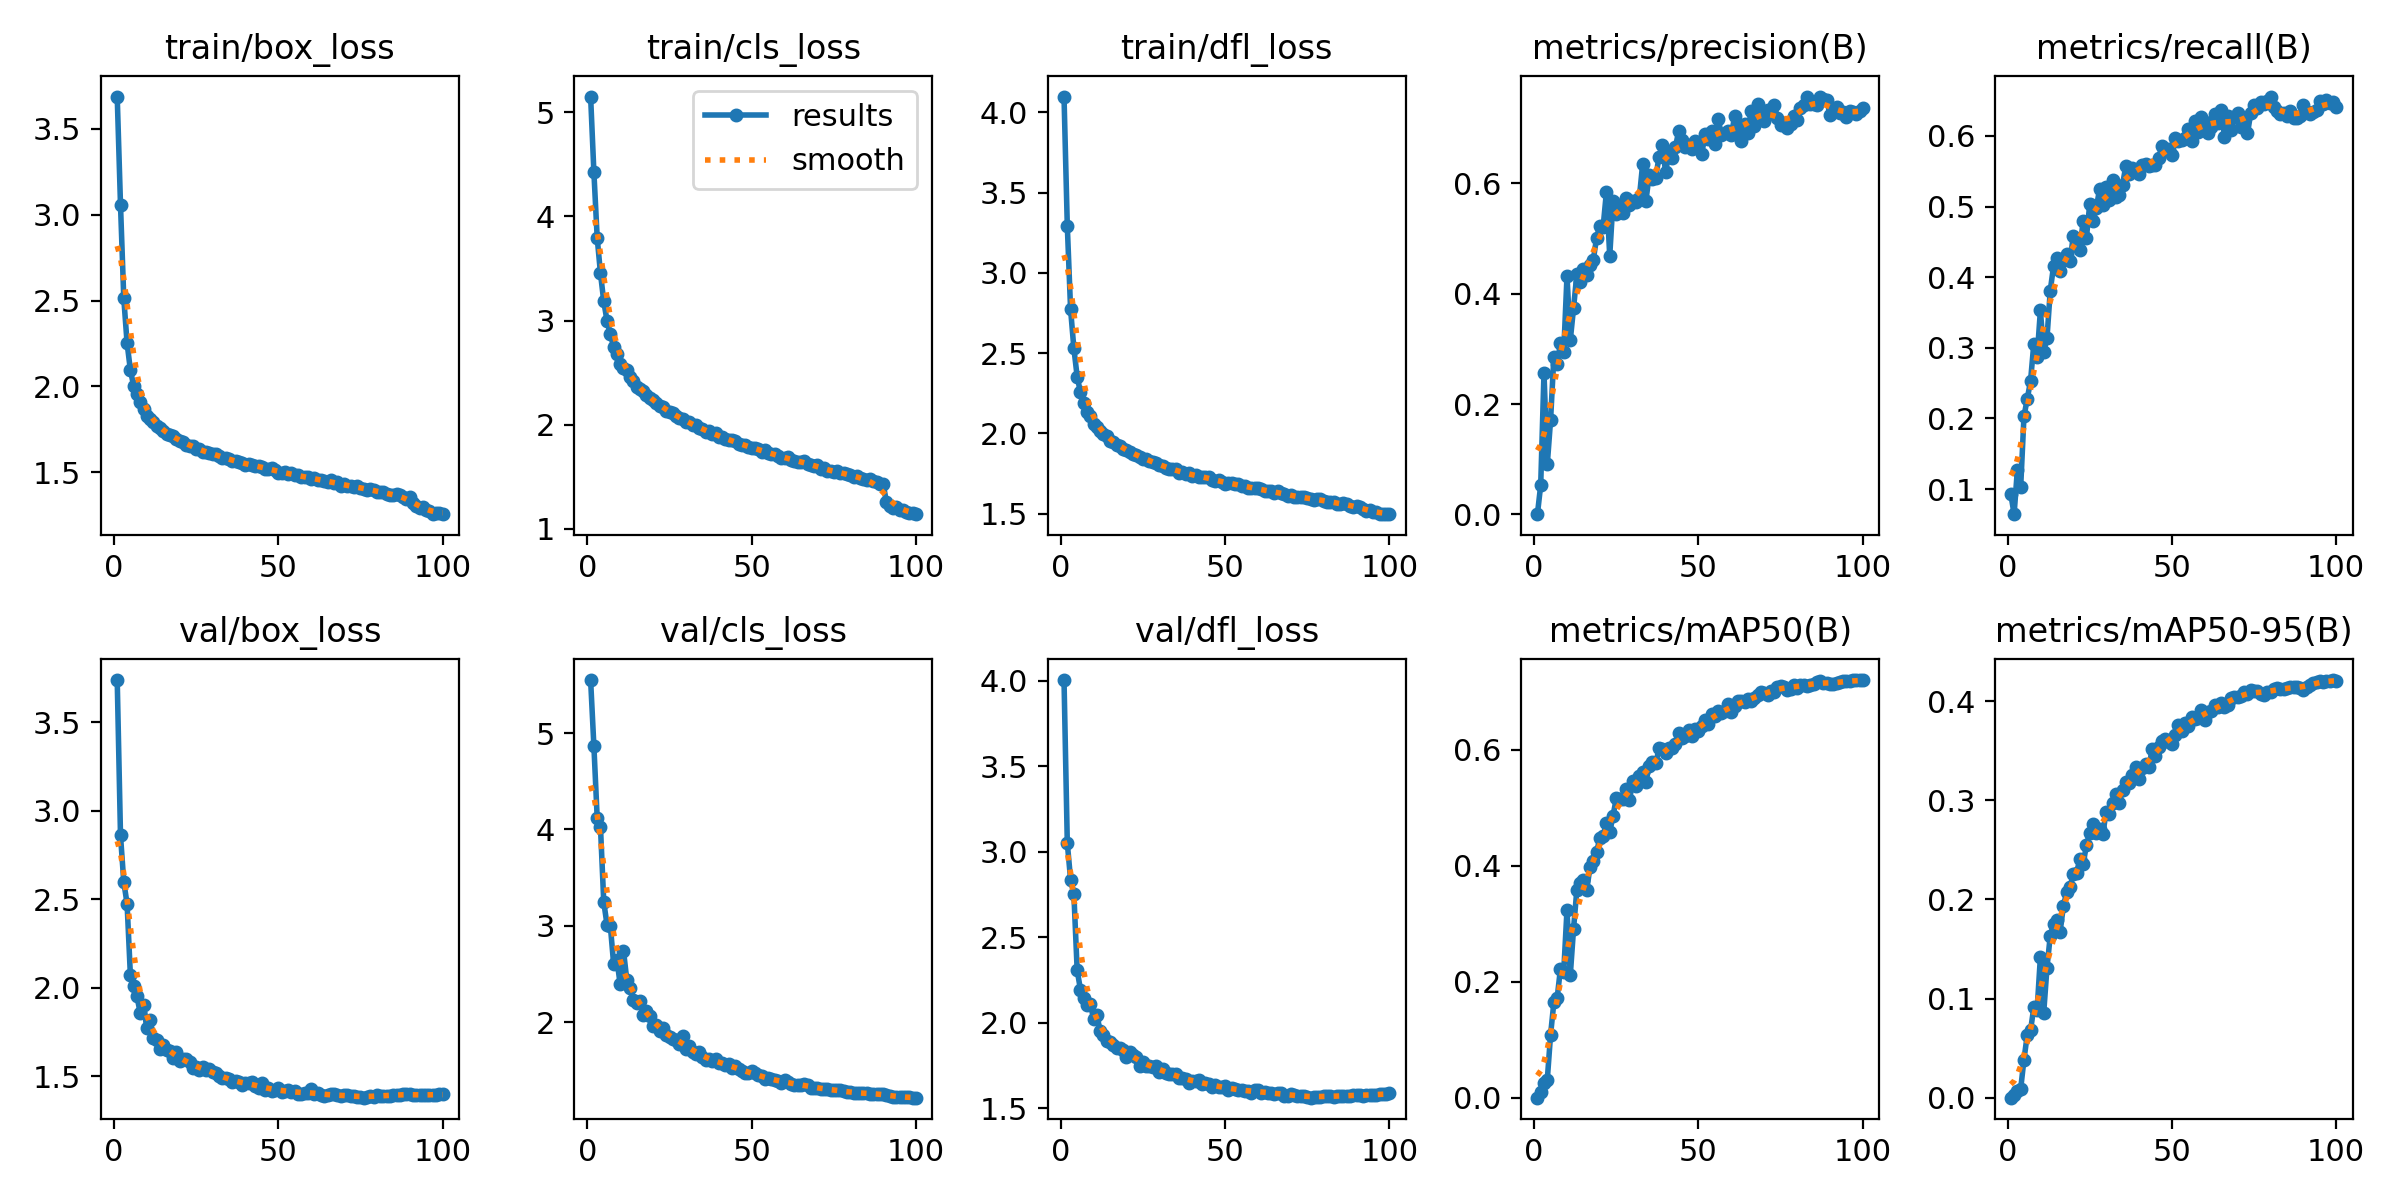

In [28]:
from IPython.display import Image, display

display(
    Image(
        filename=(
            "/kaggle/working/"
            "road_damage_final/"
            "yolov8n_p2_scconv_ema/"
            "results.png"
        )
    )
)

# Confusion matrix

confusion_matrix.png


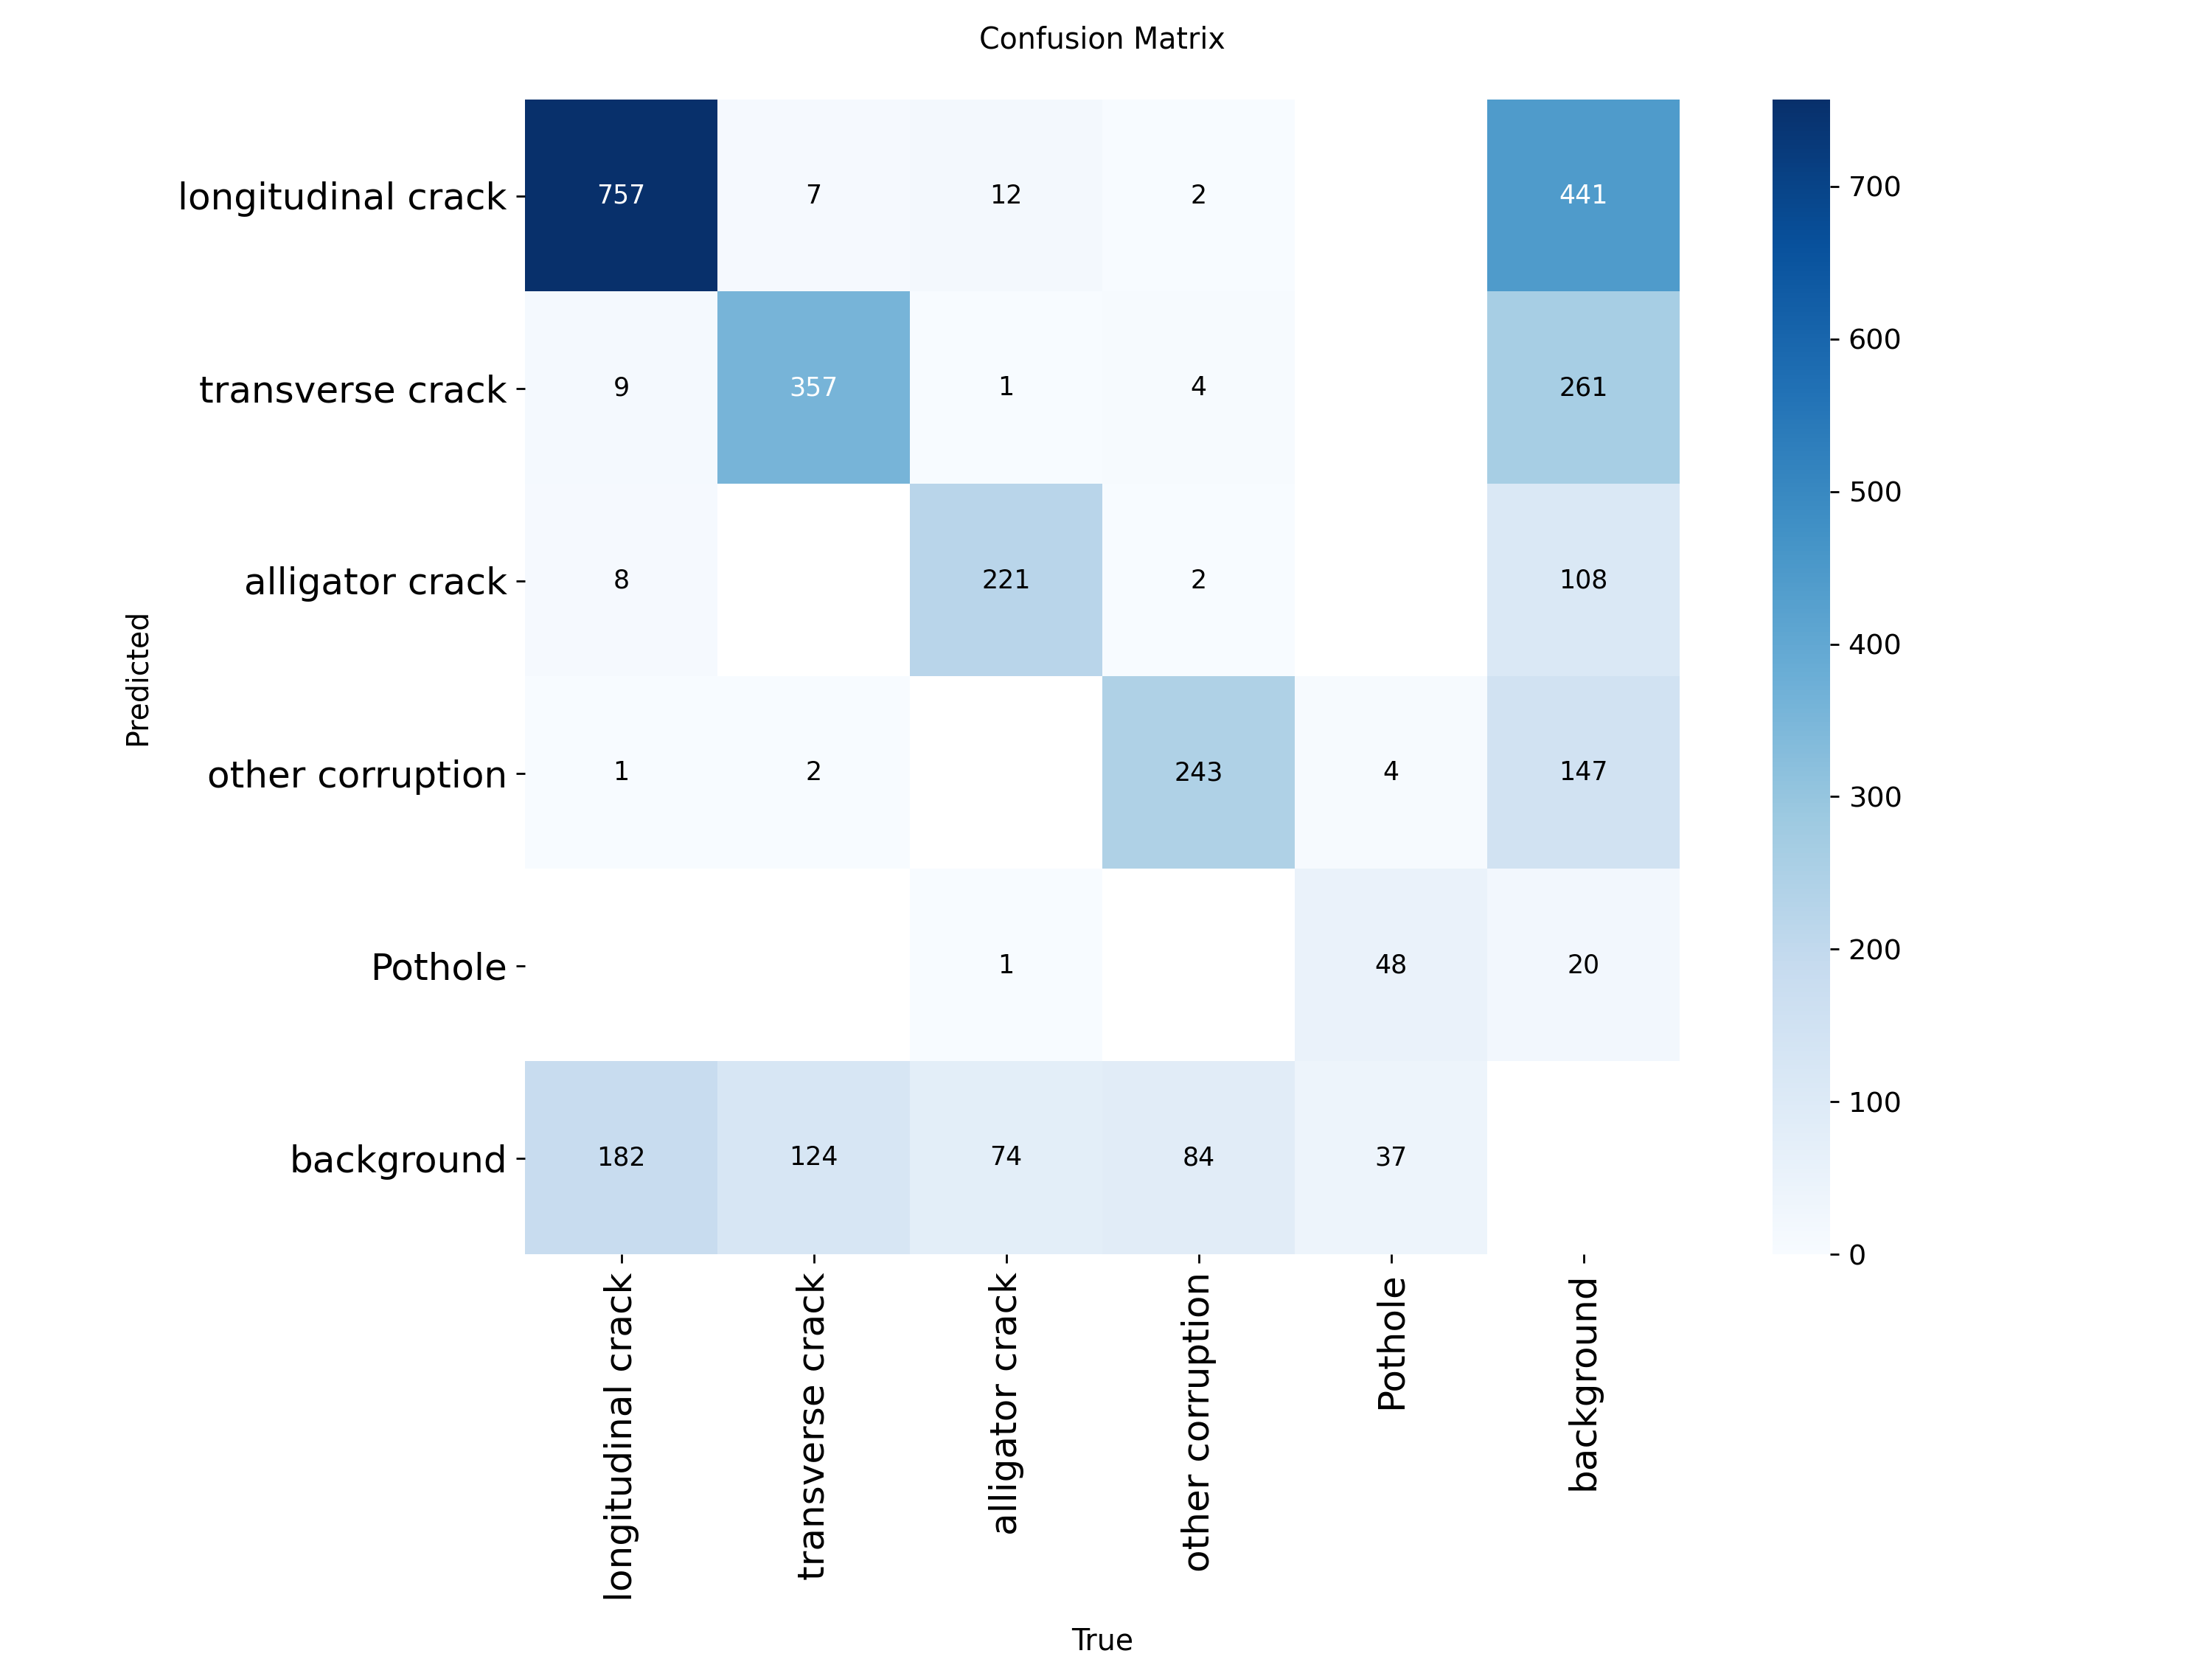

confusion_matrix_normalized.png


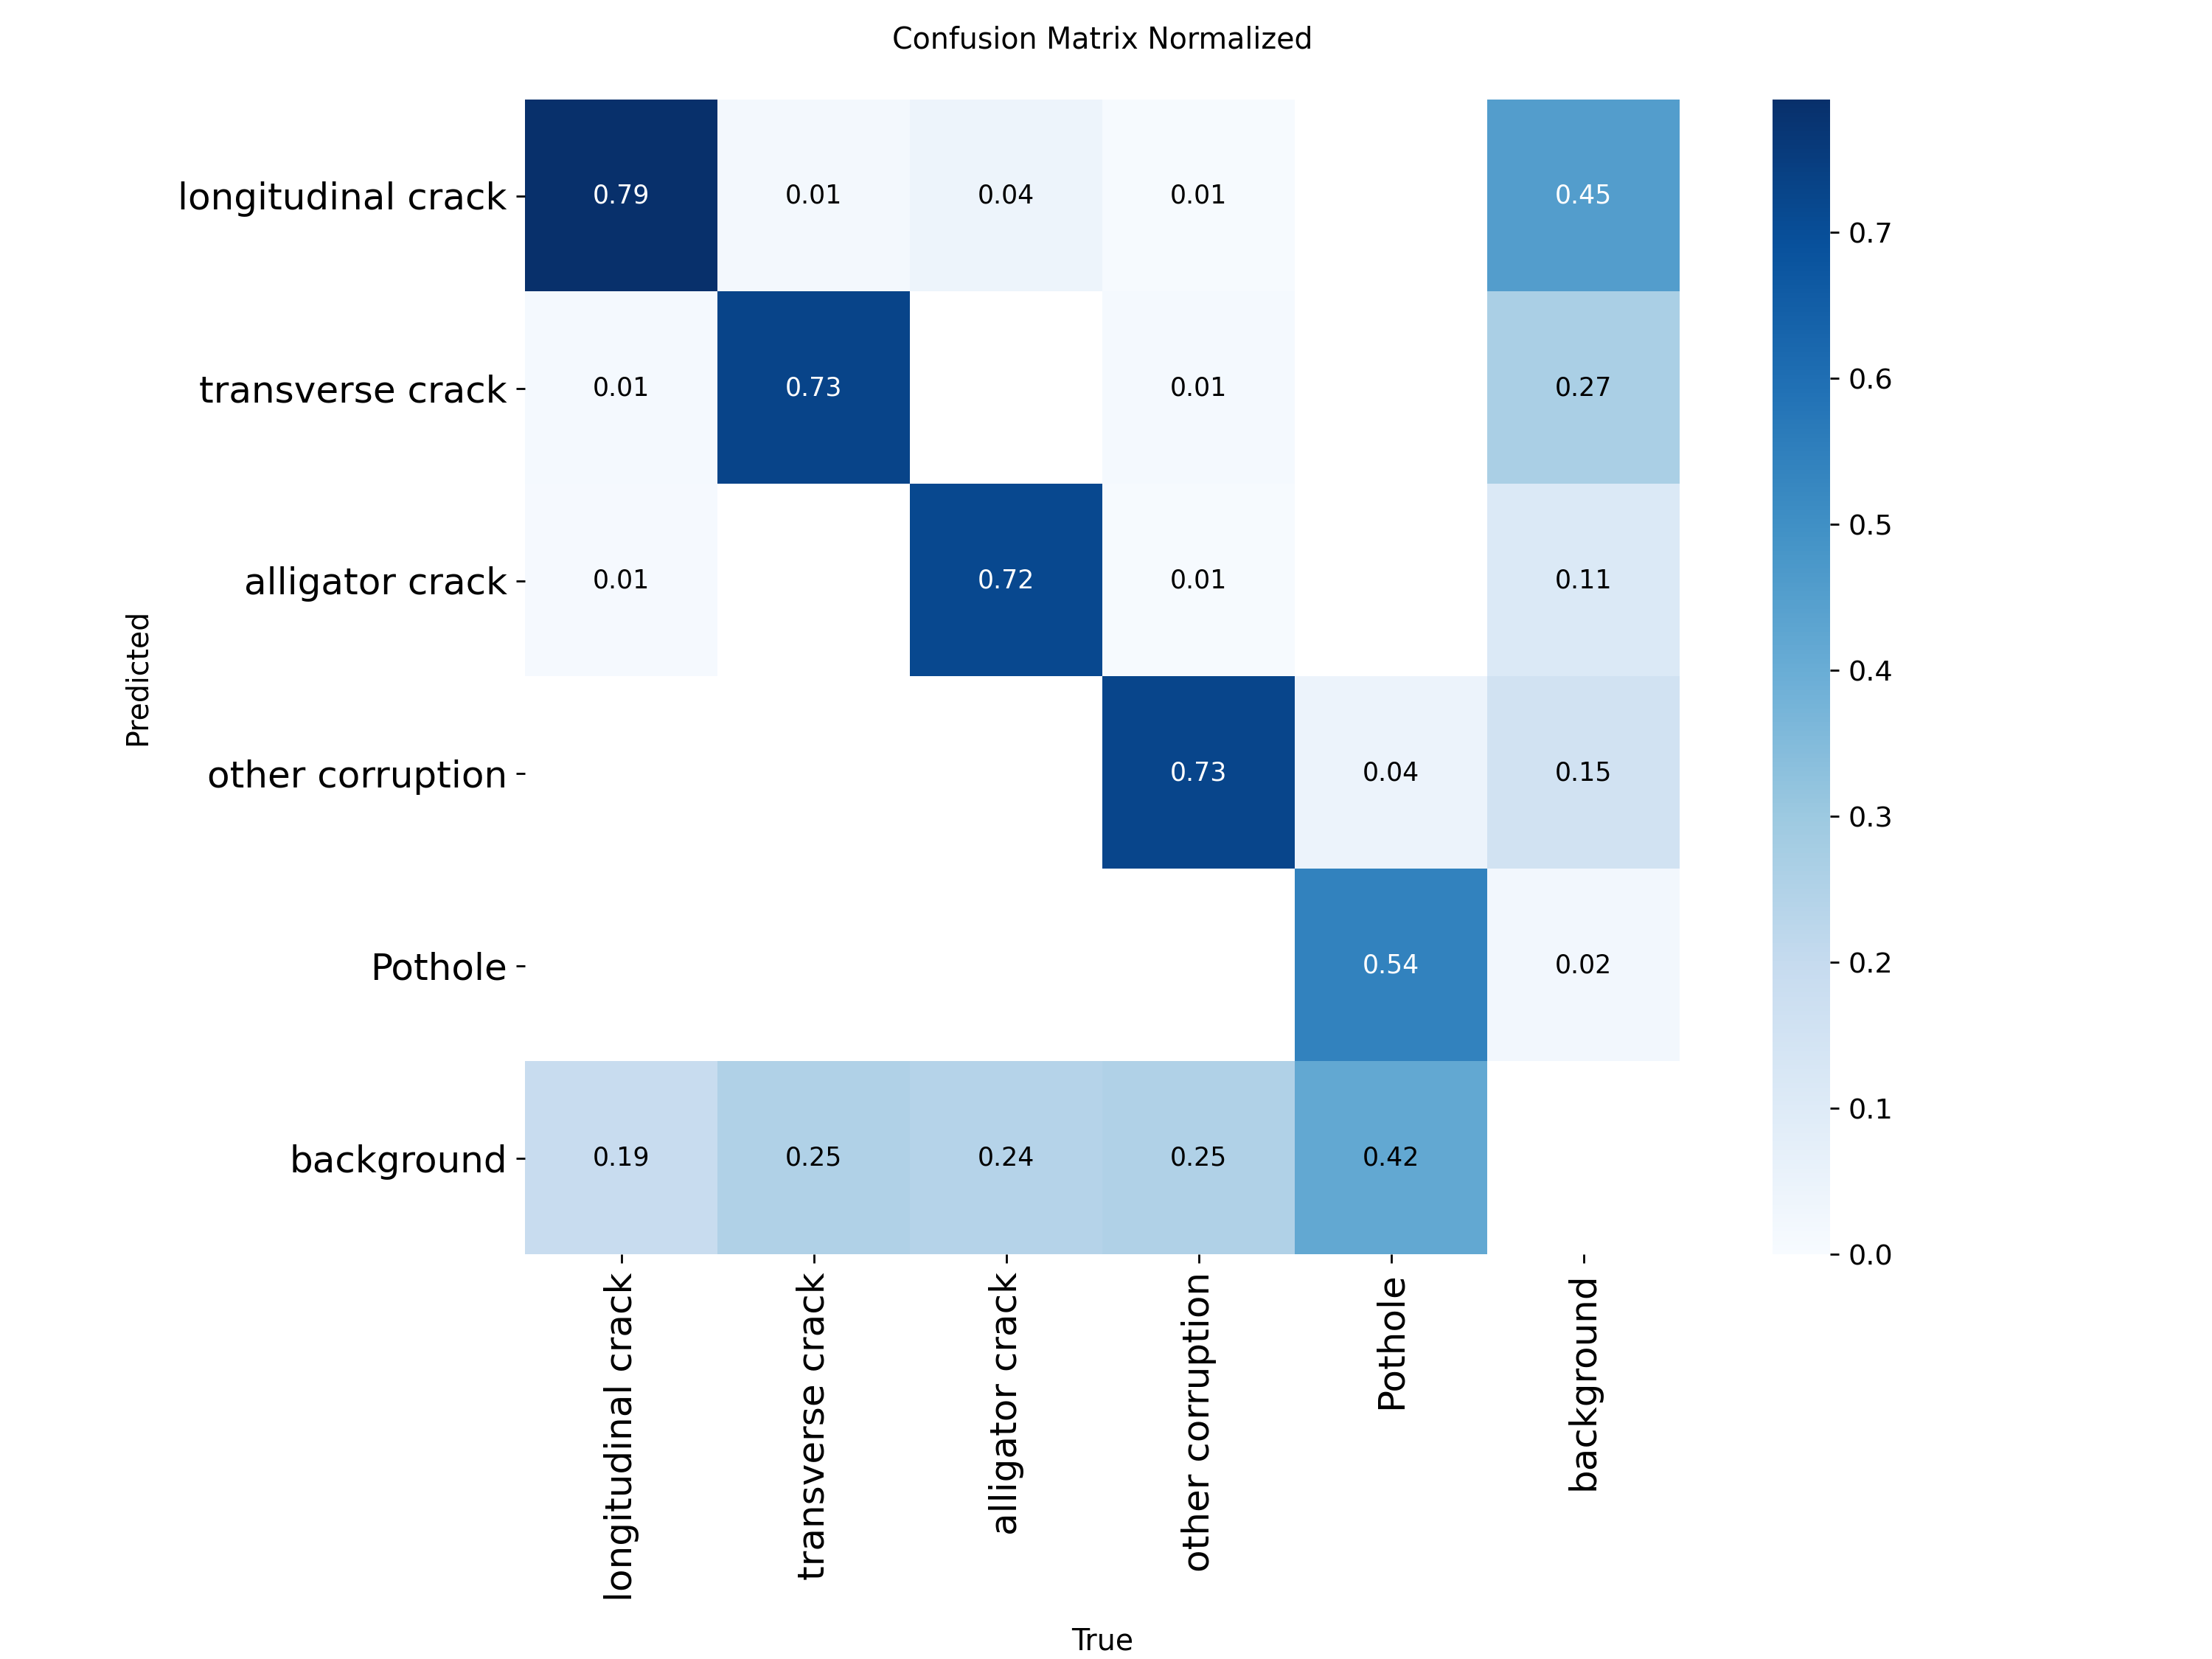

In [29]:
import os
from IPython.display import Image, display

TEST_DIR = (
    "/kaggle/working/"
    "road_damage_test/"
    "final_test"
)

for filename in [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png"
]:

    path = os.path.join(
        TEST_DIR,
        filename
    )

    if os.path.exists(path):

        print(filename)

        display(
            Image(
                filename=path
            )
        )

# PR curve

In [30]:
path = (
    "/kaggle/working/"
    "road_damage_test/"
    "final_test/"
    "PR_curve.png"
)

if os.path.exists(path):

    display(
        Image(
            filename=path
        )
    )

# F1 curve

In [31]:
path = (
    "/kaggle/working/"
    "road_damage_test/"
    "final_test/"
    "F1_curve.png"
)

if os.path.exists(path):

    display(
        Image(
            filename=path
        )
    )